# Coffee Shop Sales Analysis  
**HCT - CIS 2423 Group Project**  
**CLO1, CLO2, CLO3, CLO4**  



**Dataset:** `Coffee Sale PROJECT.csv`

In [2]:
# IMPORT LIBRARIES 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import r2_score, accuracy_score, confusion_matrix

%matplotlib inline 
plt.style.use('seaborn-v0_8')
print("All libraries imported successfully!")

All libraries imported successfully!


In [3]:
# Load Dataset 

df = pd.read_csv("../data/raw/Coffee Sale PROJECT.csv")
print("Dataset loaded. Shape:", df.shape)
df.head()

Dataset loaded. Shape: (3547, 11)


,9,cash_type,money,coffee_name,Time_of_Day,Weekday,Month_name,Weekdaysort,Monthsort,Date,Time
0,10,card,38.7,Latte,Morning,Fri,Mar,5,3,3/1/2024,15:50.5
1,12,card,38.7,Hot Chocolate,Afternoon,Fri,Mar,5,3,3/1/2024,19:22.5
2,12,card,38.7,Hot Chocolate,Afternoon,Fri,Mar,5,3,3/1/2024,20:18.1
3,13,card,28.9,Americano,Afternoon,Fri,Mar,5,3,3/1/2024,46:33.0
4,13,card,38.7,Latte,Afternoon,Fri,Mar,5,3,3/1/2024,48:14.6


In [4]:
# Data Wrangling and Cleaning 

# Convert Date
df['Date'] = pd.to_datetime(df['Date'], format='%m/%d/%Y')

# FIX: Extract hour from string (handles 46:33.0 → 46 → 16)
df['hour'] = df['Time'].astype(str).str.split(':').str[0].astype(int)
df['hour'] = df['hour'] % 24  # Fix invalid hours

# Rename money → price
df.rename(columns={'money': 'price'}, inplace=True)

# Drop duplicates
df = df.drop_duplicates()

# Remove price outliers (99th percentile)
df = df[df['price'] <= df['price'].quantile(0.99)]

# Reset index
df.reset_index(drop=True, inplace=True)

print("Data cleaning completed! Final shape:", df.shape)
print("Missing values:\n", df.isnull().sum())
df.head() 

Data cleaning completed! Final shape: (3547, 12)
Missing values:
 9              0
cash_type      0
price          0
coffee_name    0
Time_of_Day    0
Weekday        0
Month_name     0
Weekdaysort    0
Monthsort      0
Date           0
Time           0
hour           0
dtype: int64


,9,cash_type,price,coffee_name,Time_of_Day,Weekday,Month_name,Weekdaysort,Monthsort,Date,Time,hour
0,10,card,38.7,Latte,Morning,Fri,Mar,5,3,2024-03-01,15:50.5,15
1,12,card,38.7,Hot Chocolate,Afternoon,Fri,Mar,5,3,2024-03-01,19:22.5,19
2,12,card,38.7,Hot Chocolate,Afternoon,Fri,Mar,5,3,2024-03-01,20:18.1,20
3,13,card,28.9,Americano,Afternoon,Fri,Mar,5,3,2024-03-01,46:33.0,22
4,13,card,38.7,Latte,Afternoon,Fri,Mar,5,3,2024-03-01,48:14.6,0


In [5]:
# Descriptive Statistics 

print("=== Central Tendency ===")
print(f"Mean Price: {df['price'].mean():.2f}")
print(f"Median Price: {df['price'].median():.2f}")
print(f"Most Frequent Coffee: {df['coffee_name'].mode()[0]}")

print("\n=== Dispersion ===")
print(f"Standard Deviation: {df['price'].std():.2f}")
print(f"Range: {df['price'].max() - df['price'].min():.2f}")

print("\n=== Position ===")
print(f"25th Percentile: {df['price'].quantile(0.25):.2f}") 
print(f"75th Percentile: {df['price'].quantile(0.75):.2f}")

print("\n=== Coffee Sales Count ===")
print(df['coffee_name'].value_counts())

# Save stats
df['price'].describe().round(2).to_csv("../results/stats/descriptive_stats.txt")
print("\nDescriptive stats saved!") 

=== Central Tendency ===
Mean Price: 31.65
Median Price: 32.82
Most Frequent Coffee: Americano with Milk

=== Dispersion ===
Standard Deviation: 4.88
Range: 20.58

=== Position ===
25th Percentile: 27.92
75th Percentile: 35.76

=== Coffee Sales Count ===
coffee_name
Americano with Milk    809
Latte                  757
Americano              564
Cappuccino             486
Cortado                287
Hot Chocolate          276
Cocoa                  239
Espresso               129
Name: count, dtype: int64

Descriptive stats saved!


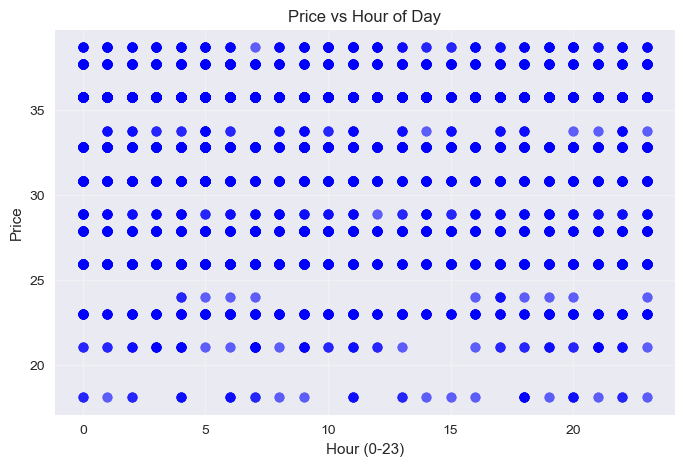

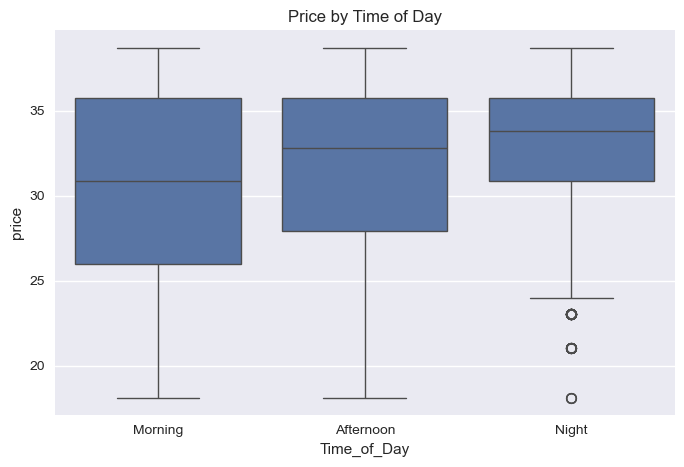

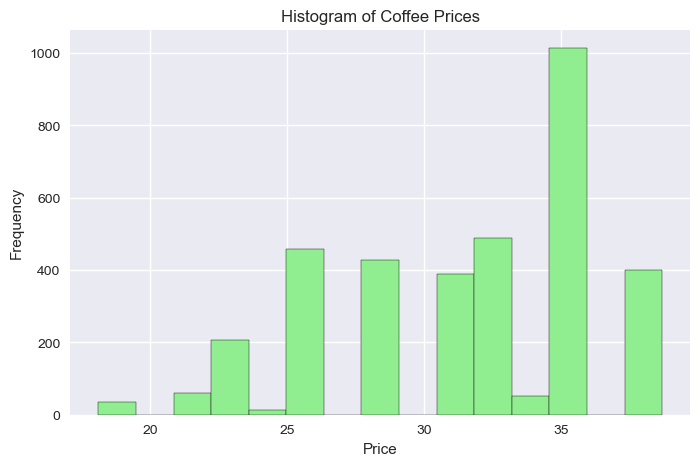

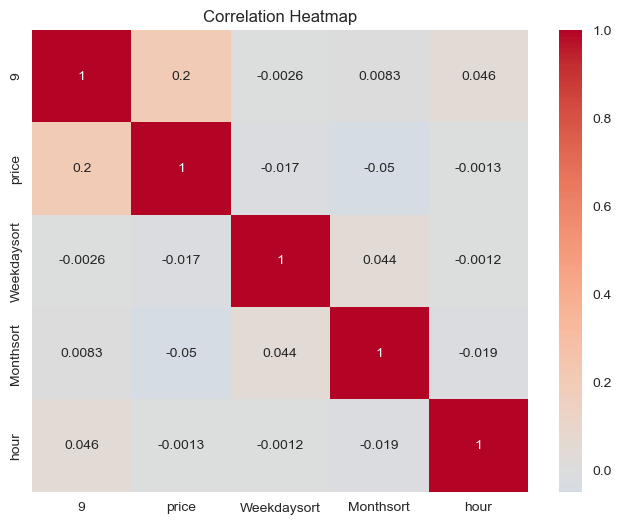

In [6]:
# Exploratory Data Analysis (EDA) Charts

import os
os.makedirs("../results/charts", exist_ok=True)

# Chart 1: Scatter
plt.figure(figsize=(8,5))
plt.scatter(df['hour'], df['price'], alpha=0.6, color='blue')
plt.title('Price vs Hour of Day')
plt.xlabel('Hour (0-23)')
plt.ylabel('Price')
plt.grid(True, alpha=0.3)
plt.savefig("../results/charts/scatter_price_hour.png")
plt.show()

# Chart 2: Boxplot
plt.figure(figsize=(8,5))
sns.boxplot(x='Time_of_Day', y='price', data=df)
plt.title('Price by Time of Day')
plt.savefig("../results/charts/boxplot_timeofday.png")
plt.show()

# Chart 3: Histogram
plt.figure(figsize=(8,5))
plt.hist(df['price'], bins=15, edgecolor='black', color='lightgreen')
plt.title('Histogram of Coffee Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.savefig("../results/charts/histogram_price.png")
plt.show() 

# Chart 4: Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.savefig("../results/charts/heatmap_corr.png")
plt.show() 

In [7]:
# Hypothesis Testing 

morning = df[df['Time_of_Day'] == 'Morning']['price']
night = df[df['Time_of_Day'] == 'Night']['price']

t_stat, p_value = ttest_ind(morning, night, nan_policy='omit')

print(f"T-statistic: {t_stat:.4f}") 
print(f"P-value: {p_value:.4f}")

if p_value < 0.05:
    print("REJECT H0: Significant difference between Morning and Night prices.")
else:
    print("FAIL TO REJECT H0: No significant difference.") 

T-statistic: -12.7150
P-value: 0.0000
REJECT H0: Significant difference between Morning and Night prices.


In [8]:
# Data Preprocessing for ML 

le_coffee = LabelEncoder()
df['coffee_enc'] = le_coffee.fit_transform(df['coffee_name'])

le_time = LabelEncoder()
df['time_enc'] = le_time.fit_transform(df['Time_of_Day'])

print("Encoded: coffee_enc, time_enc")
df[['coffee_name', 'coffee_enc', 'Time_of_Day', 'time_enc']].head()

Encoded: coffee_enc, time_enc


,coffee_name,coffee_enc,Time_of_Day,time_enc
0,Latte,7,Morning,1
1,Hot Chocolate,6,Afternoon,0
2,Hot Chocolate,6,Afternoon,0
3,Americano,0,Afternoon,0
4,Latte,7,Afternoon,0


In [9]:
# Regression Model – Predict Price 

X = df[['coffee_enc', 'time_enc', 'hour']]
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)
regressor = LinearRegression()
regressor.fit(X_train, y_train)

y_pred = regressor.predict(X_test)
r2 = r2_score(y_test, y_pred)

print(f"R² Score: {r2:.3f}")
print(f"Equation: Price = {regressor.intercept_:.2f} + {regressor.coef_[0]:.2f}×coffee + {regressor.coef_[1]:.2f}×time + {regressor.coef_[2]:.2f}×hour") 


R² Score: 0.216
Equation: Price = 28.62 + 0.82×coffee + 0.48×time + -0.00×hour


In [10]:
# Classification – Predict Coffee Type 

X_cls = df[['price', 'hour', 'time_enc']]
y_cls = df['coffee_name']

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_cls, y_cls, test_size=0.2, random_state=0)
classifier = KNeighborsClassifier(n_neighbors=5)
classifier.fit(X_train_c, y_train_c)

y_pred_c = classifier.predict(X_test_c)
acc = accuracy_score(y_test_c, y_pred_c)

print(f"Accuracy: {acc:.3f}")
print("Confusion Matrix:\n", confusion_matrix(y_test_c, y_pred_c)) 

Accuracy: 0.483
Confusion Matrix:
 [[ 79  18   0   0  18   0   0   0]
 [  8 125   5   0   1   0   0  23]
 [  0  10  44  10   0   0   9  27]
 [  0   2  19   5   0   0   2  13]
 [ 26  15   0   0  16   0   0   0]
 [  7   0   0   0   1  15   0   0]
 [  0   1  25   8   0   0   8  19]
 [  0  19  48  20   0   0  13  51]]


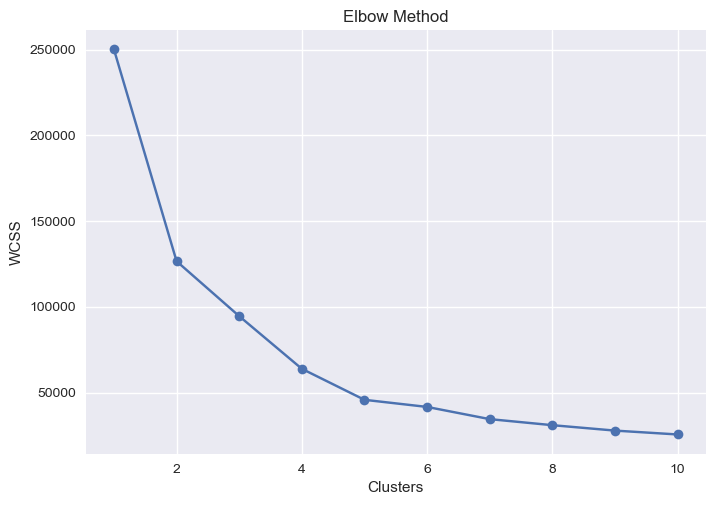

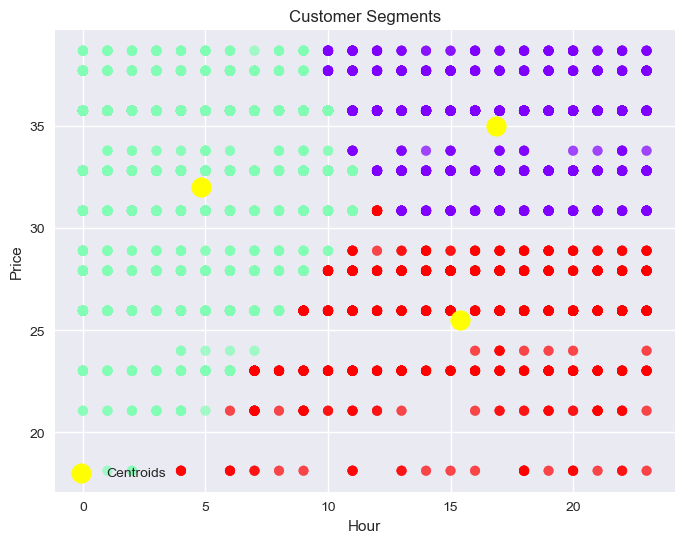

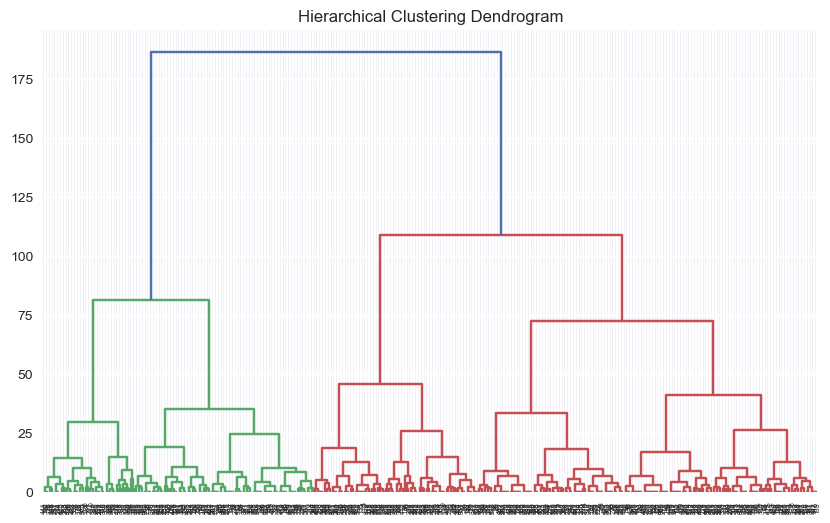

Clustering: 3 groups found!


In [11]:
# Clustering – CUSTOMER SEGMENTATION

X_cluster = df[['price', 'hour']]
wcss = [KMeans(n_clusters=i, random_state=0).fit(X_cluster).inertia_ for i in range(1, 11)]

plt.plot(range(1,11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Clusters')
plt.ylabel('WCSS')
plt.savefig("../results/charts/elbow_plot.png")
plt.show()

# K=3
kmeans = KMeans(n_clusters=3, random_state=0)
df['cluster'] = kmeans.fit_predict(X_cluster)

plt.figure(figsize=(8,6))
plt.scatter(df['hour'], df['price'], c=df['cluster'], cmap='rainbow', alpha=0.7)
plt.scatter(kmeans.cluster_centers_[:,1], kmeans.cluster_centers_[:,0], s=200, c='yellow', label='Centroids')
plt.title('Customer Segments')
plt.xlabel('Hour')
plt.ylabel('Price')
plt.legend()
plt.savefig("../results/charts/cluster_plot.png")
plt.show()

from scipy.cluster.hierarchy import dendrogram, linkage
Z = linkage(df[['price', 'hour']].sample(500), method='ward')
plt.figure(figsize=(10,6))
dendrogram(Z)
plt.title('Hierarchical Clustering Dendrogram')
plt.savefig("../results/charts/dendrogram.png")
plt.show()

print("Clustering: 3 groups found!") 


In [ ]:
# Save Processed Data 

df.to_csv("../data/processed/processed_coffee.csv", index=False)
print("Saved to: ../data/processed/processed_coffee.csv")  

Saved to: ../data/processed/processed_coffee.csv


# Conclusion

- **Best Time:** Afternoon (highest price)  
- **Top Coffee:** Latte  
- **3 Segments:** Morning, Afternoon, Night buyers  
- **Recommendation:** Increase Latte stock in Afternoon   
- **p-value:** <0.05 → Morning ≠ Night prices 